In [2]:
#Use only twice to run the program and comment the code again
#%pip install -r ../requirements.txt

In [3]:
#Personal note, remember to put all import module in here

#tbh, I rather see the imports called inside the code cell of needed, or it just a beginner view to import placement?

In [4]:
import pandas as pd
weather = pd.read_excel("../dataset/openmeteo_makassar_weather.xlsx")

In [5]:
weather.to_csv("../dataset/openmeteo_makassar_weather.csv")

In [6]:
input = weather.drop(['time','temperature_2m_mean'], axis = 1)
output = weather['temperature_2m_mean']

In [7]:
input.head()

,temperature_2m_max,sunshine_duration,precipitation_sum,apparent_temperature_mean,wind_speed_10m_max,shortwave_radiation_sum,weather_code,temperature_2m_min
0,28.0,32535.21,6.9,31.4,12.3,16.71,61,24.8
1,28.1,40311.63,2.8,31.5,14.5,19.30,61,25.3
2,28.3,35355.65,1.4,31.5,14.3,16.99,53,24.7
3,27.0,29237.88,7.5,30.9,10.4,15.13,61,25.1
4,27.4,18944.19,30.3,29.9,13.8,11.56,63,24.5


In [8]:
output.head()

0    26.6
1    26.6
2    26.4
3    25.9
4    25.3
Name: temperature_2m_mean, dtype: float64

## 80:20 Data Split
With the amount of training data being 80% and test data being 20%:

In [9]:
#Split the dataset: 80% for training and 20% for testing
from sklearn.model_selection import train_test_split
X_train,X_test,y_train, y_test = train_test_split(input,output, test_size=0.2,random_state = 1)

In [10]:
#Linear Regression Model Training
from sklearn import linear_model
import time

#Measure training execution time
time_start = time.perf_counter()
reg_linear = linear_model.LinearRegression()
reg_linear.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_linear = reg_linear.predict(X_test)

In [11]:
#Check if the test set and prediction dimensions match
print("Jumlah data ujian: ", y_test.shape)
print("Jumlah data tebakan: ", predict_linear.shape)

Jumlah data ujian:  (1169,)
Jumlah data tebakan:  (1169,)


In [12]:
#Linear Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_reg_linear = mae(y_test, predict_linear)
rmse_reg_linear = rmse(y_test,predict_linear)
mape_reg_linear = mape(y_test,predict_linear)
r2_reg_linear = r2(y_test,predict_linear)
duration_reg_linear = end_time - time_start

print('Linear Regression MAE: {}'.format(mae_reg_linear))
print('Linear Regression RMSE: {}'.format(rmse_reg_linear))
print('Linear Regression MAPE: {}'.format(mape_reg_linear))
print('Linear Regression R2 Score: {}'.format(r2_reg_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_reg_linear))



Linear Regression MAE: 0.16784578366724767
Linear Regression RMSE: 0.2129307050004794
Linear Regression MAPE: 0.006272326115257438
Linear Regression R2 Score: 0.9521352704520258
Training Duration: 0.010940 Seconds


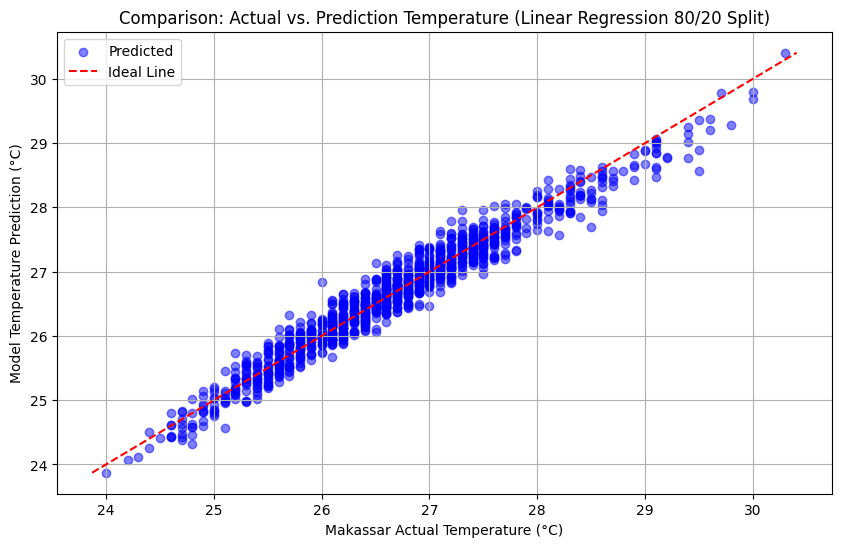

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_linear.min())
max_val = max(y_test.max(), predict_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Linear Regression 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [14]:
#Gradient Boosting Model Training
from sklearn.ensemble import GradientBoostingRegressor
import time

#Measure training execution time
time_start = time.perf_counter()
reg_gra_bost = GradientBoostingRegressor()
reg_gra_bost.fit(X_train,y_train) #fitting the model to the training data
end_time = time.perf_counter()

#Perform prediction on the test set
predict_gra_bost = reg_gra_bost.predict(X_test)

In [15]:
#Gradient Boosting Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_gra_bost = mae(y_test, predict_gra_bost)
rmse_gra_bost = rmse(y_test,predict_gra_bost)
mape_gra_bost = mape(y_test,predict_gra_bost)
r2_gra_bost = r2(y_test,predict_gra_bost)
duration_gra_bost = end_time - time_start

print('Gradient Boosting Regression MAE : {}'.format(mae_gra_bost))
print('Gradient Boosting Regression RMSE: {}'.format(rmse_gra_bost))
print('Gradient Boosting Regression MAPE: {}'.format(mape_gra_bost))
print('Gradient Boosting Regression R2: {}'.format(r2_gra_bost))
print('Training Duration: {:.6f} Seconds'.format(duration_gra_bost))

Gradient Boosting Regression MAE : 0.1376119668983459
Gradient Boosting Regression RMSE: 0.17685756662933522
Gradient Boosting Regression MAPE: 0.005138282587602467
Gradient Boosting Regression R2: 0.9669792969331877
Training Duration: 0.477338 Seconds


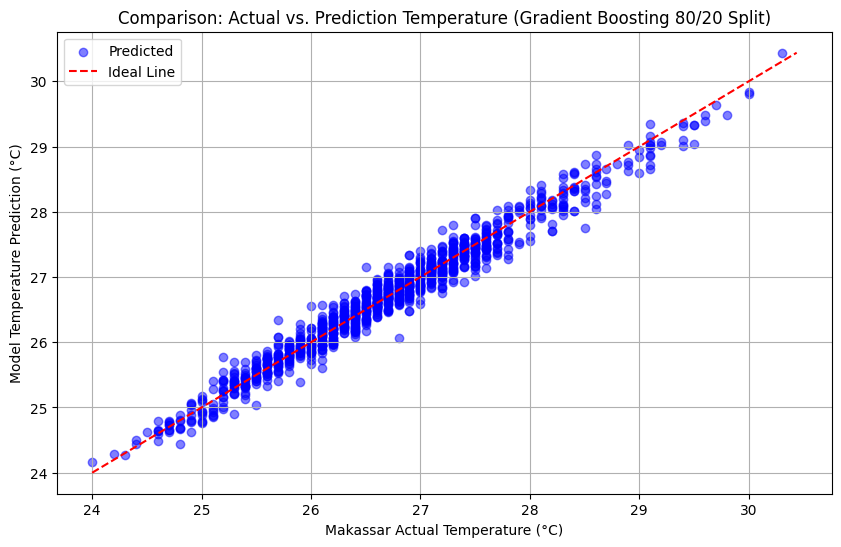

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_gra_bost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_gra_bost.min())
max_val = max(y_test.max(), predict_gra_bost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Gradient Boosting 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [17]:
#Adaboost Regression Model Training 
from sklearn.ensemble import AdaBoostRegressor
import time

time_start = time.perf_counter()
reg_adaboost = AdaBoostRegressor()
reg_adaboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_adaboost = reg_adaboost.predict(X_test)

In [18]:
#Adaboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_adaboost = mae(y_test, predict_adaboost)
rmse_adaboost = rmse(y_test,predict_adaboost)
mape_adaboost = mape(y_test,predict_adaboost)
r2_adaboost = r2(y_test,predict_adaboost)
duration_adaboost = end_time - time_start

print('AdaBoost Regression MAE Model Regresi: {}'.format(mae_adaboost))
print('AdaBoost Regression RMSE Model Regresi: {}'.format(rmse_adaboost))
print('AdaBoost Regression MAPE Model Regresi: {}'.format(mape_adaboost))
print('AdaBoost Regression R2 Model Regresi: {}'.format(r2_adaboost))
print('Training Duration: {:.6f} Seconds'.format(duration_adaboost))

AdaBoost Regression MAE Model Regresi: 0.209631437793005
AdaBoost Regression RMSE Model Regresi: 0.2642624989589726
AdaBoost Regression MAPE Model Regresi: 0.007876138290359954
AdaBoost Regression R2 Model Regresi: 0.9262757946147229
Training Duration: 0.223878 Seconds


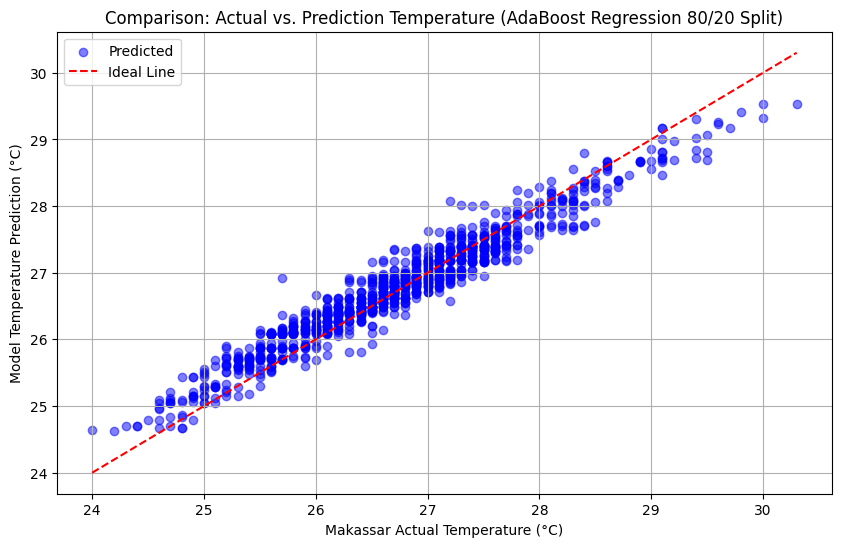

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_adaboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_adaboost.min())
max_val = max(y_test.max(), predict_adaboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (AdaBoost Regression 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
#XGBoost Regression Model Training
from xgboost import XGBRegressor
import time

time_start = time.perf_counter()
reg_xgboost = XGBRegressor()
reg_xgboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_xgboost = reg_xgboost.predict(X_test)

In [21]:
#XGBoost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_xgboost = mae(y_test, predict_xgboost)
rmse_xgboost = rmse(y_test,predict_xgboost)
mape_xgboost = mape(y_test,predict_xgboost)
r2_xgboost = r2(y_test,predict_xgboost)
duration_xgboost = end_time - time_start

print('XGboost Regression MAE: {}'.format(mae_xgboost))
print('XGboost Regression RMSE: {}'.format(rmse_xgboost))
print('XGboost Regression MAPE: {}'.format(mape_xgboost))
print('XGboost Regression R2: {}'.format(r2_xgboost))
print('Training Duration: {:.6f} Seconds'.format(duration_xgboost))

XGboost Regression MAE: 0.1402700063609179
XGboost Regression RMSE: 0.18234047563062022
XGboost Regression MAPE: 0.005233000178035907
XGboost Regression R2: 0.9649001555422163
Training Duration: 0.153129 Seconds


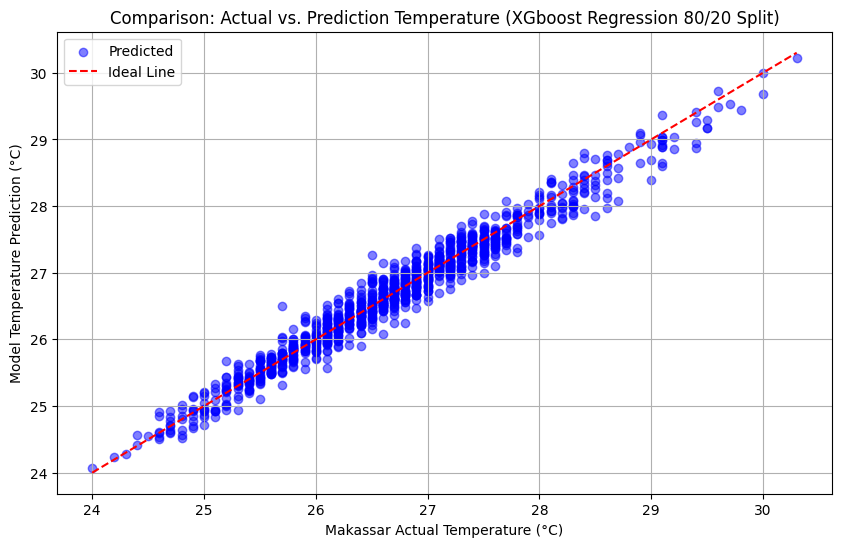

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_xgboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_xgboost.min())
max_val = max(y_test.max(), predict_xgboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (XGboost Regression 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [23]:
#CatBoost Regression Model Training
from catboost import CatBoostRegressor
import time

time_start = time.perf_counter()
reg_catboost = CatBoostRegressor()
reg_catboost.fit(X_train,y_train)
end_time = time.perf_counter()

predict_catboost = reg_catboost.predict(X_test)

Learning rate set to 0.05224
0:	learn: 0.9506012	total: 78.7ms	remaining: 1m 18s
1:	learn: 0.9103052	total: 80ms	remaining: 39.9s
2:	learn: 0.8711045	total: 81.1ms	remaining: 26.9s
3:	learn: 0.8352651	total: 82.3ms	remaining: 20.5s
4:	learn: 0.8010344	total: 83.4ms	remaining: 16.6s
5:	learn: 0.7693300	total: 84.5ms	remaining: 14s
6:	learn: 0.7381114	total: 85.6ms	remaining: 12.1s
7:	learn: 0.7090460	total: 86.7ms	remaining: 10.8s
8:	learn: 0.6811173	total: 87.9ms	remaining: 9.68s
9:	learn: 0.6542473	total: 89ms	remaining: 8.81s
10:	learn: 0.6282971	total: 90.1ms	remaining: 8.1s
11:	learn: 0.6046002	total: 91.2ms	remaining: 7.51s
12:	learn: 0.5823816	total: 92.5ms	remaining: 7.02s
13:	learn: 0.5607078	total: 93.6ms	remaining: 6.59s
14:	learn: 0.5399715	total: 94.7ms	remaining: 6.22s
15:	learn: 0.5213584	total: 95.8ms	remaining: 5.89s
16:	learn: 0.5026102	total: 96.9ms	remaining: 5.61s
17:	learn: 0.4851408	total: 98.2ms	remaining: 5.36s
18:	learn: 0.4689687	total: 99.3ms	remaining: 5.13s

In [24]:
#Catboost Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_catboost = mae(y_test, predict_catboost)
rmse_catboost = rmse(y_test,predict_catboost)
mape_catboost = mape(y_test,predict_catboost)
r2_catboost = r2(y_test,predict_catboost)
duration_catboost = end_time - time_start

print('CatBoost Regression MAE: {}'.format(mae_catboost))
print('CatBoost Regression RMSE: {}'.format(rmse_catboost))
print('CatBoost Regression MAPE: {}'.format(mape_catboost))
print('CatBoost Regression R2: {}'.format(r2_catboost))
print('Training Duration: {:.6f} Seconds'.format(duration_catboost))

CatBoost Regression MAE: 0.12659813865552416
CatBoost Regression RMSE: 0.16456182229344996
CatBoost Regression MAPE: 0.004724480594772205
CatBoost Regression R2: 0.9714111160893042
Training Duration: 1.369187 Seconds


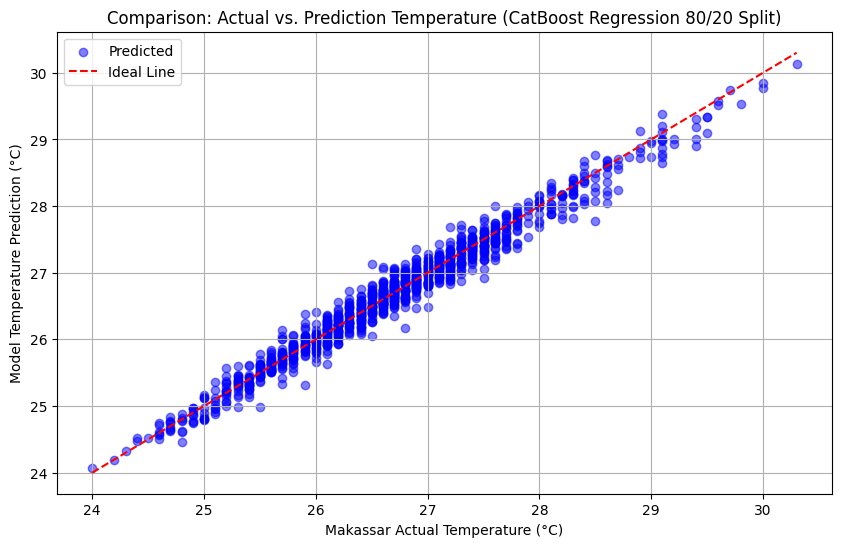

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_catboost, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_catboost.min())
max_val = max(y_test.max(), predict_catboost.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (CatBoost Regression 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
#Light GBM Regression Model Training
from lightgbm import LGBMRegressor
import time

time_start = time.perf_counter()
reg_lightgbm = LGBMRegressor()
reg_lightgbm.fit(X_train,y_train)
end_time = time.perf_counter()

predict_lightgbm = reg_lightgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000890 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1225
[LightGBM] [Info] Number of data points in the train set: 4675, number of used features: 8
[LightGBM] [Info] Start training from score 26.664813


In [27]:
#LightGBM Regression Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_lightgbm = mae(y_test, predict_lightgbm)
rmse_lightgbm = rmse(y_test,predict_lightgbm)
mape_lightgbm = mape(y_test,predict_lightgbm)
r2_lightgbm = r2(y_test,predict_lightgbm)
duration_lightgbm = end_time - time_start

print('LightGBM Regression MAE: {}'.format(mae_lightgbm))
print('LightGBM Regression RMSE: {}'.format(rmse_lightgbm))
print('LightGBM Regression MAPE: {}'.format(mape_lightgbm))
print('LightGBM Regression R2: {}'.format(r2_lightgbm))
print('Training Duration: {:.6f} Seconds'.format(duration_lightgbm))

LightGBM Regression MAE: 0.13456598835624373
LightGBM Regression RMSE: 0.17398564361922977
LightGBM Regression MAPE: 0.005018713743123729
LightGBM Regression R2: 0.9680430109810275
Training Duration: 1.299295 Seconds


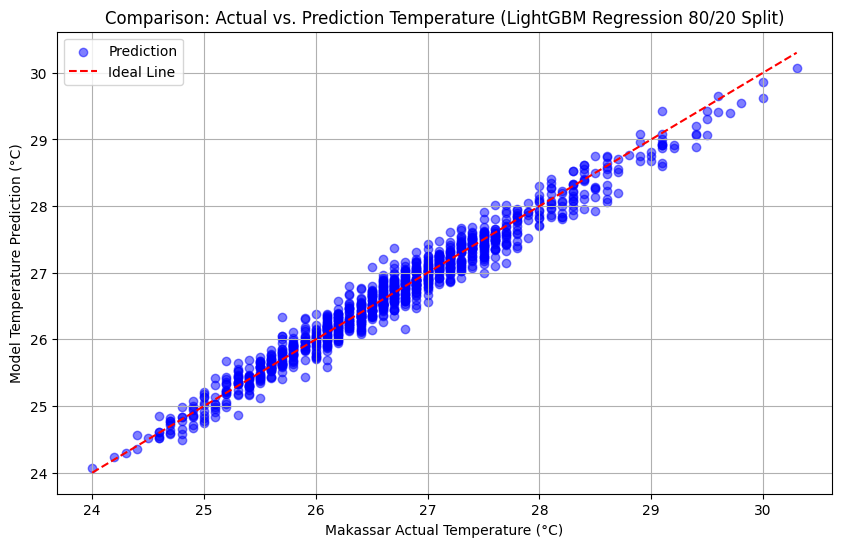

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_lightgbm, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_lightgbm.min())
max_val = max(y_test.max(), predict_lightgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (LightGBM Regression 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
#SVR Linear Regression Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_linear = make_pipeline(StandardScaler(), SVR(kernel='linear',C=1.0, epsilon=0.2))
reg_svl_linear.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_linear = reg_svl_linear.predict(X_test)

In [30]:
#Linear SVR Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_linear = mae(y_test, predict_svl_linear)
rmse_svl_linear = rmse(y_test,predict_svl_linear)
mape_svl_linear = mape(y_test,predict_svl_linear)
r2_svl_linear = r2(y_test,predict_svl_linear)
duration_svl_linear = end_time - time_start

print('Linear SVR MAE: {}'.format(mae_svl_linear))
print('Linear SVR RMSE: {}'.format(rmse_svl_linear))
print('Linear SVR MAPE: {}'.format(mape_svl_linear))
print('Linear SVR R2: {}'.format(r2_svl_linear))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_linear))

Linear SVR MAE: 0.1680414633411251
Linear SVR RMSE: 0.21296310212700634
Linear SVR MAPE: 0.0062794564609694485
Linear SVR R2: 0.9521207042327829
Training Duration: 0.640648 Seconds


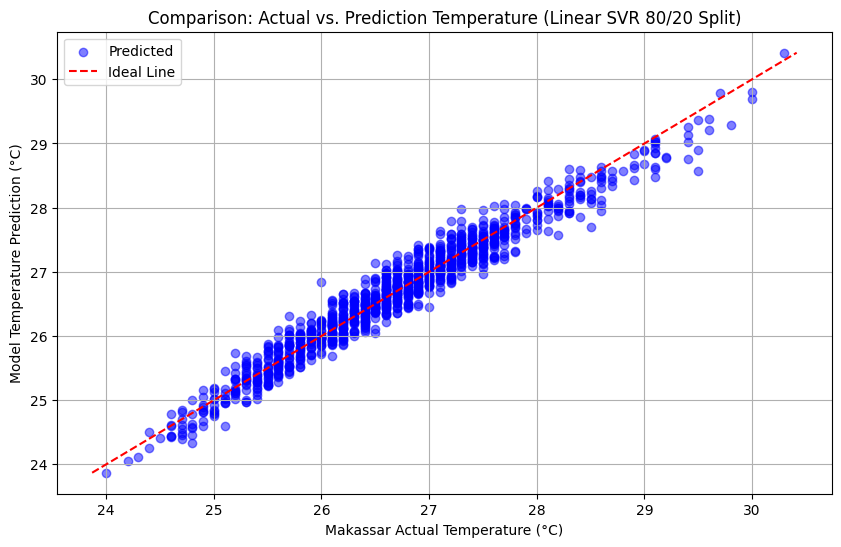

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_linear, alpha=0.5, color='blue', label='Predicted')
min_val = min(y_test.min(), predict_svl_linear.min())
max_val = max(y_test.max(), predict_svl_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (Linear SVR 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [32]:
#SVR RBF Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_rbf = make_pipeline(StandardScaler(), SVR(kernel='rbf',C=1.0, epsilon=0.2))
reg_svl_rbf.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_rbf = reg_svl_rbf.predict(X_test)

In [33]:
#SVR RBF Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_rbf = mae(y_test, predict_svl_rbf)
rmse_svl_rbf = rmse(y_test,predict_svl_rbf)
mape_svl_rbf = mape(y_test,predict_svl_rbf)
r2_svl_rbf = r2(y_test,predict_svl_rbf)
duration_svl_rbf = end_time - time_start

print('SVR RBF MAE: {}'.format(mae_svl_rbf))
print('SVR RBF RMSE: {}'.format(rmse_svl_rbf))
print('SVR RBF MAPE: {}'.format(mape_svl_rbf))
print('SVR RBF R2: {}'.format(r2_svl_rbf))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_rbf))

SVR RBF MAE: 0.12878395887589758
SVR RBF RMSE: 0.16740545214793406
SVR RBF MAPE: 0.00480360438373332
SVR RBF R2: 0.9704145471131047
Training Duration: 0.140233 Seconds


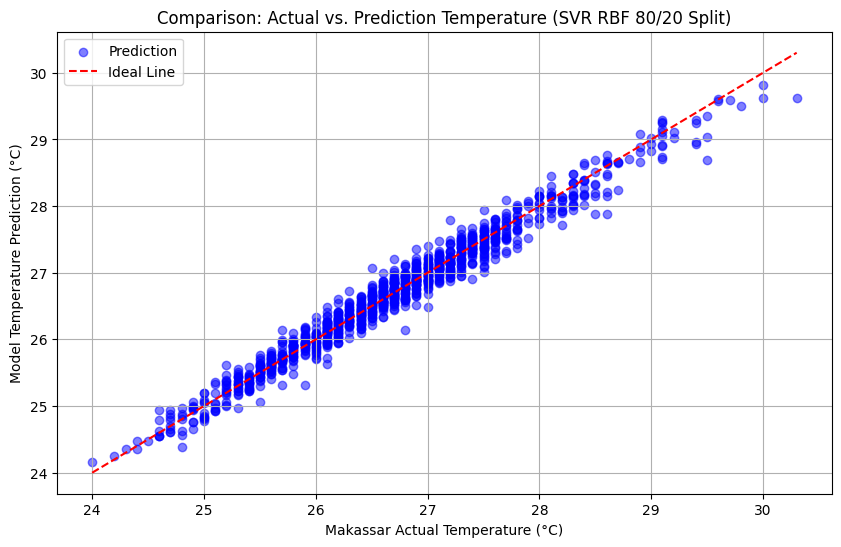

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_rbf, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_svl_rbf.min())
max_val = max(y_test.max(), predict_svl_rbf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (SVR RBF 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()

In [35]:
#SVR Polynomial Model Training
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

time_start = time.perf_counter()
reg_svl_poly = make_pipeline(StandardScaler(), SVR(kernel='poly',C=1.0, epsilon=0.2))
reg_svl_poly.fit(X_train,y_train)
end_time = time.perf_counter()

predict_svl_poly = reg_svl_poly.predict(X_test)

In [36]:
#SVR Polynomial Evaluation Metrics
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score as r2

mae_svl_poly = mae(y_test, predict_svl_poly)
rmse_svl_poly = rmse(y_test,predict_svl_poly)
mape_svl_poly = mape(y_test,predict_svl_poly)
r2_svl_poly = r2(y_test,predict_svl_poly)
duration_svl_poly = end_time - time_start

print('SVR Polynomial MAE: {}'.format(mae_svl_poly))
print('SVR Polynomial RMSE: {}'.format(rmse_svl_poly))
print('SVR Polynomial MAPE: {}'.format(mape_svl_poly))
print('SVR Polynomial R2: {}'.format(r2_svl_poly))
print('Training Duration: {:.6f} Seconds'.format(duration_svl_poly))

SVR Polynomial MAE: 0.2998536702349727
SVR Polynomial RMSE: 0.400025399879642
SVR Polynomial MAPE: 0.01125107664893086
SVR Polynomial R2: 0.8310671296122498
Training Duration: 0.744687 Seconds


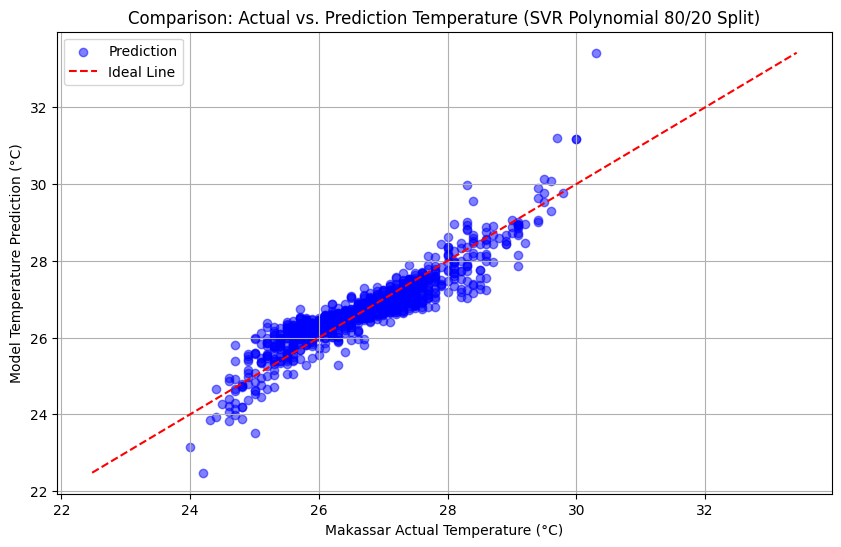

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predict_svl_poly, alpha=0.5, color='blue', label='Prediction')
min_val = min(y_test.min(), predict_svl_poly.min())
max_val = max(y_test.max(), predict_svl_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Line')
plt.title('Comparison: Actual vs. Prediction Temperature (SVR Polynomial 80/20 Split)')
plt.xlabel('Makassar Actual Temperature (°C)')
plt.ylabel('Model Temperature Prediction (°C)')
plt.legend()
plt.grid(True)

plt.show()